## Colab 환경에서 실행 시 환경 설정

In [1]:
# 구글 드라이브의 폴더와 구글 코랩 폴더 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 현재 경로 확인
!pwd

/content


In [3]:
# drive/MyDrive/Colab Notebooks 경로로 변경
# %cd drive/MyDrive/'Colab Notebooks'

%cd drive/MyDrive/Colab/20250509

[Errno 2] No such file or directory: 'drive/MyDrive/Colab/20250509'
/content


#### 코랩에서 한국어 표시하기

In [4]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 84.1 MB/s eta 0:00:00


In [5]:
import koreanize_matplotlib

# 🔖 자연어 처리

<a id="lecture_index"></a>
## 수업 목차

[1. Transformer](#six)<br>
- Transformer 모델 특징
- Transformer 구조 시각화 및 수식
- Transformer 구성요소 및 PyTorch 구현

## <a id='one'>1️⃣ Transformer</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## Transformer

> 오직 어텐션 메커니즘의 조합만으로도 복잡한 시퀀스 생성까지 가능함을 입증한 모델 아키텍처 <br>

## 개발 배경
> 💡 Attention의 등장에도 불구하고 여전히 RNN 계열 모델에서 벗어나지 못하여, 순차 모델의 특성상 병렬처리를 하지 못한다는 한계가 있었음 <br>
> 양방향 RNN 모델의 사용으로 앞 뒤 문맥은 파악 가능하지만 여전히 양 끝단에 있는 단어간의 연관성은 이해하지 못하는 장기 의존성 문제가 있음 <br>
> context vector가 모든 시점의 단어의 문맥 정보를 담고 있지만 여전히 weighted sum 된 하나의 벡터이기 때문에 디코더는 전체 문장을 요약한 단일 벡터에만 의존하게 되고, 문장이 길거나 중요한 정보가 여러 위치에 흩어져 있을 경우 정보 손실이나 표현력의 한계가 발생할 수 있다

## ✅ Transformer 모델 특징

#### ① 장기 의존성 문제 해결
- RNN은 시간이 지날수록 정보가 희석되어 멀리 떨어진 토큰 간 관계를 학습하기 어렵지만, Transformer는 모든 입력 토큰 간의 직접적인 Attention 경로를 가지기 때문에 이러한 문제가 크게 줄어듦
#### ② 병렬 처리 가능
- RNN 계열은 순차적 처리가 필수이지만, Transformer는 모든 토큰을 동시에 처리할 수 있어 학습 속도가 빠름
#### ③ Self-Attention
-  각 토큰이 전체 입력 문맥(context)을 고려해 가중치를 부여함
- 입력의 각 위치가 다른 모든 위치에 대해 얼마나 주의를 기울일지를 학습
#### ④ Position Encoding
- Transformer는 순서를 처리하는 내장 구조가 없기 때문에, 토큰의 순서 정보를 위치 인코딩으로 주입
#### ⑤ Multi-Head Attention
- 여러 개의 Self-Attention을 병렬로 수행하여 다양한 관점의 표현 학습
- 서로 다른 하위 공간에서 관계를 추출하므로 정보 표현력이 강화됨
#### ⑥ Residual Connection & Layer Normalization
- Residual Connection은 기울기 소실 완화 및 학습 안정화
- Layer Normalization은 특성 분포를 정규화하여 학습을 더 빠르고 안정적으로 만듦
#### ⑦ Encoder-Decoder 구조
- Encoder: 입력 전체를 context로 압축
- Decoder: 이를 기반으로 단계적으로 출력 생성

## Transformer 구조 시각화 및 수식

<center>
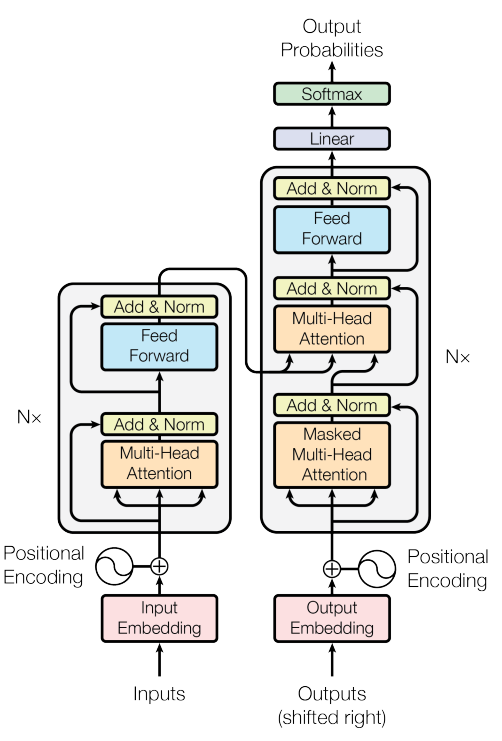
</center>

### Self-Attention

> 한 문장 안에서 단어들이 서로 얼마나 중요한지 파악하는 메커니즘 (개념) <br>
> 한 문장 안에서 각 단어들간의 유사도를 확인하여 각 단어에 문맥 정보를 잘 담게 하는 것이 목적

#### 작동 방식 (순서)

1. 문장에서 각 단어를 Query로 삼고
2. 나머지 단어들을 Key로 삼아서
3. 유사도(중요도)를 계산하고
4. Value로부터 정보를 가져온다

| 용어            | 역할                             |
| ------------- | ------------------------------ |
| **Query (Q)** | 지금 처리 중인 단어가 “다른 단어에게 질문하는 벡터” |
| **Key (K)**   | 각 단어가 가지고 있는 “자신에 대한 설명”       |
| **Value (V)** | 각 단어의 실질적인 정보 (문맥 벡터)          |

### Positional Encoding

> 🚀 순서 개념이 없는 Self-Attention 메커니즘에 단어의 위치 정보를 주입하는 방법 <br>
> Transformer에서는 전체 문장을 동시에 처리하기 때문에 각 단어의 위치 정보를 명시적으로 주지 않으면 순서를 알 수 없다 <br>
> 따라서, 단어 위치 정보를 벡터로 만들고 Token Embedding에 더해주는 방식으로 위치 정보를 추가한다

### Scaled Dot-Product Attention

> self-attention을 수학적으로 어떻게 계산해야 하는지 정리한 공식

<center>
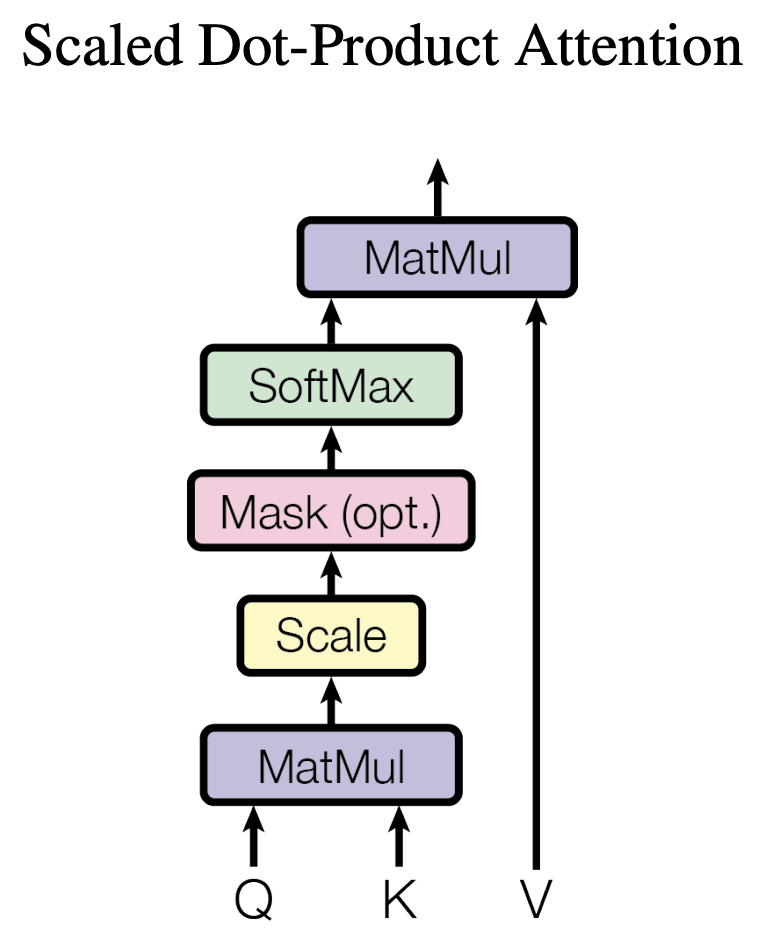
</center>

<center>
<h3>수식</h3>
</center>

$$
\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{QK^\top}{\sqrt{d_k}} \right)V
$$

<center>
<h3>구성 요소</h3>
</center>

In [28]:
import math
import torch
import torch.nn as nn
import numpy as np

In [79]:
# d_model: input_sequence의 enbedding_dim / head: multi_head_attention어서 head의 수
def self_attentions(input_sequence, d_model, head):
    dk = math.sqrt(int((d_model / head)))

    Q = input_sequence  # (Batch, Sequence, Enbedding)
    K = input_sequence
    V = input_sequence

    QK = torch.matmul(Q, K.transpose(2, 1)) # (Batch, Sequence, Sequence)

    temp = torch.softmax(QK / dk, dim=-1) # (Batch, Sequence, Sequence)

    attention = torch.matmul(temp, V) # (Batch, Sequence, Sequence) @ (Batch, Sequence, Enbedding)

    return attention    # (Batch, Sequence, Enbedding)

In [83]:
input_sequence = torch.arange(3 * 4 * 5, dtype=torch.float16).reshape(3, 4, 5)

In [84]:
input_sequence.shape

torch.Size([3, 4, 5])

In [85]:
self_attentions(input_sequence, 5, 1)

tensor([[[15., 16., 17., 18., 19.],
         [15., 16., 17., 18., 19.],
         [15., 16., 17., 18., 19.],
         [15., 16., 17., 18., 19.]],

        [[35., 36., 37., 38., 39.],
         [35., 36., 37., 38., 39.],
         [35., 36., 37., 38., 39.],
         [35., 36., 37., 38., 39.]],

        [[55., 56., 57., 58., 59.],
         [55., 56., 57., 58., 59.],
         [55., 56., 57., 58., 59.],
         [55., 56., 57., 58., 59.]]], dtype=torch.float16)

$$
1. \ Q: Query \ (질문하는 \ 벡터 \ 👉 \ "이 단어가 다른 단어들과 얼마나 연관이 있니?") \\
2. \ K: Key \ (각각의 \ 단어 \ 스스로를 \ 구성하는 \ 정보 \ 벡터 \  👉 \ "각각의 \ 단어는 \ 이런 \ 정보를 \ 가지고 \ 있어") \\
np.arrat3. \ V: Value \ (각 \ 단어가 \ 갖고 \ 있는 \ '의미 \ 표현' \ 벡터 \ 👉 \ "각각의 \ 단어의 \ 진짜 \ 정보는 \ 이거야") \\
4. \ \sqrt{d_k} \ 스케일링 \ 팩터 \\
5. \ QK^T: \ Query와 \ Key의 \ 내적 \ 👉 \ 유사도, \ 두 \ 벡터가 \ 얼마나 \ 관련 \ 있는가
$$

<center>
dk: Query-Key 유사도 계산을 위한 내적 차원  ex) (Batch, sequence_length, dk) <br>
dv: Query-Key와 Value의 가중합 계산으로 생기는 출력 차원 ex) (Batch, sequence_length, dv) <br>

dk, dv 차원은 출력 차원을 얼만큼 할 것인가를 나타내는 차원으로 직접 지정해주는 값 임 <br>
하지만 입력 시퀀스와 연산을 위해서 embedding dim(d_model)과 맞춰줘야함 <br>
한 가지 더 dk, dv 차원을 구하는 것을 어렵게 하는 요소가 하나 있는데, 그건 바로 attention을 하나만 사용하지 않는 다는 점 <br>
결론적으로 attention을 얼만큼 병렬적으로 사용하는지 개수와 임베딩 차원을 고려하여 dk, dv 차원을 구해야 함 <br>
<br>
🚀 dk = d_model / num_head (attention 개수) <br>
⚠️ dv는 보통 dk와 동일하게 하지만, 실험적으로, 메모리 최적화 등의 문제로 줄이는 경우가 있음. 단, 최종 output shape을 맞춰주면 됨
</center>

### 💡 Q, K, V는 모두 입력 시퀀스 벡터로 부터 만들어지기 때문에 초기에는 모두 같은 벡터나 다름 없음. <br>
###    하지만, 위 수식이 적용된 채로 학습을 하면, 각각 Q, K, V 가중치 행렬은 위에서 언급한 역할이 자연스럽게 부여됨

### Multi-Head Attention

> 여러 개의 Self-Attention을 병렬로 수행한 뒤, 그 결과를 합쳐 표현력을 높이는 구조 <br>
> 단일 Self-Attetion 구조라면 특정 관점에서만 연관성을 연산하기 때문에 표현력의 제한이 생김 <br>
> 따라서 표현력을 높이기 위해 여러개의 Self-Attention을 사용 <br>
> 예) "나는", "배가", "고프다" -> Q = "나는" K = "고프다" 일때 단일 self-attention 이라면 <br>
> 둘 사이의 관계가 문법적 관계인지, 감정적 연결인지, 의미적 유사성인지 따로 분리해서 알 수 없음

<center>
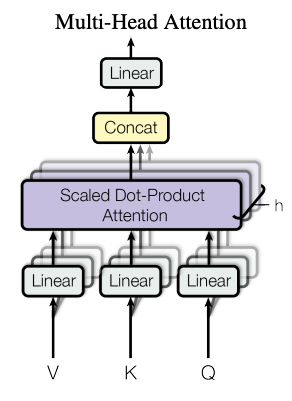
</center>

<center>
<h3> 수식 </h3>
</center>

$$
\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)
$$

$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)W^O
$$

<center>
W^o: 독립적인 head의 조합들을 하나의 통합 표현으로 만들기 위한 학습 가능한 선형 변환 (정보 재조합) 및 shape 맞추기
</center>

In [149]:
import torch.nn as nn
class SingleHeadAttention(nn.Module):
    def __init__(self, embedding_dim):
        super(SingleHeadAttention, self).__init__()
        """
        input_sequence: (Batch, Sequence, Embedding dim)
        d_model: embedding_dim
        head: head 개수
        dk: d_model
        """
        self.d_model = embedding_dim
        self.dk = embedding_dim
        self.W_Q = nn.Linear(embedding_dim, embedding_dim)
        self.W_K = nn.Linear(embedding_dim, embedding_dim)
        self.W_V = nn.Linear(embedding_dim, embedding_dim)

    def forward(self, input_sequence):
        Q = self.W_Q(input_sequence)    # (Batch, Sequence, Enbedding) @ (Embedding, Embedding) -> (B, S, E)
        K = self.W_K(input_sequence)
        V = self.W_V(input_sequence)

        QK = torch.matmul(Q, K.transpose(2, 1)) # (B, S, E) @ (B, E, S) -> (B, S, S)
        temp = torch.softmax(QK / math.sqrt(self.dk), dim=-1)

        attention = torch.matmul(temp, V) # (B, S, S) @ (B, S, E) -> (B, S, E)

        return attention

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, head):
        super(MultiHeadAttention, self).__init__()
        self.head = head
        self.d_model = d_model
        self.dk = d_model // head
        self.W_O = nn.Linear(d_model * head, d_model)

    def forward(self, input_sequence):
        multi_attention = [SingleHeadAttention(self.d_model) for _ in range(self.head)]
        multi_attention = [attention(input_sequence) for i, attention in enumerate(multi_attention)]

        multihead_attention = torch.cat(multi_attention, dim=-1)

        multi_atte = self.W_O(multihead_attention)

        return multi_atte

In [245]:
# GPT 가 짜준 코드

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, head):
        super().__init__()
        self.head = head
        self.d_model = d_model
        self.d_k = d_model // head

        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)

    def forward(self, x):  # x: (B, S, d_model)
        B, S, _ = x.shape

        Q = self.W_Q(x).view(B, S, self.head, self.d_k).transpose(1, 2)  # (B, head, S, d_k)
        K = self.W_K(x).view(B, S, self.head, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, S, self.head, self.d_k).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        weights = torch.softmax(scores, dim=-1)
        attn = torch.matmul(weights, V)  # (B, head, S, d_k)

        concat = attn.transpose(1, 2).contiguous().view(B, S, self.d_model)
        return self.W_O(concat)

In [130]:
embedding_dim = 512
head = 8

In [150]:
test = torch.arange(3 * 5 * 512, dtype=torch.float32).reshape(3, 5, 512)

In [151]:
MultiHeadAttention(512, 8)(test)

tensor([[[   89.6163,  -504.8787,   971.3978,  ..., -1249.4061,
            929.8259,    33.2128],
         [   89.6163,  -504.8787,   971.3978,  ..., -1249.4061,
            929.8259,    33.2128],
         [   89.6163,  -504.8787,   971.3978,  ..., -1249.4061,
            929.8259,    33.2128],
         [   89.6163,  -504.8787,   971.3978,  ..., -1249.4061,
            929.8259,    33.2128],
         [  363.1892,  -350.6814,   887.0338,  ..., -1346.2560,
            887.5811,  -247.4139]],

        [[  703.0878,  -623.9532,  1904.0208,  ..., -2627.2490,
           2109.8726,  -460.2943],
         [  703.0878,  -623.9532,  1904.0208,  ..., -2627.2490,
           2109.8726,  -460.2943],
         [  703.0878,  -623.9532,  1904.0208,  ..., -2627.2490,
           2109.8726,  -460.2943],
         [  703.0878,  -623.9532,  1904.0208,  ..., -2627.2490,
           2109.8726,  -460.2943],
         [  703.0878,  -623.9532,  1904.0208,  ..., -2627.2490,
           2109.8726,  -460.2943]],

      

In [144]:
# d_model: input_sequence의 enbedding_dim / head: multi_head_attention어서 head의 수
def self_attentions(input_sequence, d_model, head):
    dk = math.sqrt(int((d_model / head)))

    Q = input_sequence  # (Batch, Sequence, Enbedding)
    K = input_sequence
    V = input_sequence

    QK = torch.matmul(Q, K.transpose(2, 1)) # (Batch, Sequence, Sequence)

    temp = torch.softmax(QK / dk, dim=-1) # (Batch, Sequence, Sequence)

    attention = torch.matmul(temp, V) # (Batch, Sequence, Sequence) @ (Batch, Sequence, Enbedding)

    return attention    # (Batch, Sequence, Enbedding)

In [152]:
ttt = torch.arange(5 * 6 * 7, dtype=torch.float32).reshape(5, 6, 7)
nnn = nn.Linear(7, 3)

In [154]:
nnn(ttt)

tensor([[[ 2.1670e+00, -5.6888e-02, -9.4009e-01],
         [ 5.4658e+00, -1.8459e+00, -3.9293e+00],
         [ 8.7646e+00, -3.6350e+00, -6.9184e+00],
         [ 1.2063e+01, -5.4241e+00, -9.9076e+00],
         [ 1.5362e+01, -7.2131e+00, -1.2897e+01],
         [ 1.8661e+01, -9.0022e+00, -1.5886e+01]],

        [[ 2.1960e+01, -1.0791e+01, -1.8875e+01],
         [ 2.5258e+01, -1.2580e+01, -2.1864e+01],
         [ 2.8557e+01, -1.4369e+01, -2.4854e+01],
         [ 3.1856e+01, -1.6158e+01, -2.7843e+01],
         [ 3.5155e+01, -1.7947e+01, -3.0832e+01],
         [ 3.8454e+01, -1.9737e+01, -3.3821e+01]],

        [[ 4.1752e+01, -2.1526e+01, -3.6810e+01],
         [ 4.5051e+01, -2.3315e+01, -3.9799e+01],
         [ 4.8350e+01, -2.5104e+01, -4.2789e+01],
         [ 5.1649e+01, -2.6893e+01, -4.5778e+01],
         [ 5.4947e+01, -2.8682e+01, -4.8767e+01],
         [ 5.8246e+01, -3.0471e+01, -5.1756e+01]],

        [[ 6.1545e+01, -3.2260e+01, -5.4745e+01],
         [ 6.4844e+01, -3.4049e+01, -5.7734e

In [155]:
import math
import torch

In [244]:
def positional_encoding(input_embedding_vector):
    B, S, E = input_embedding_vector.shape
    pos = torch.zeros(S, E)

    position = torch.arange(0, S).unsqueeze(1)
    i = torch.arange(0, E).unsqueeze(0)
    denominator = 10000 ** (2 * i / E)
    pd = position / denominator

    pos[:, 1::2] = torch.sin(pd[:, 1::2])

    pos[:, 0::2] = torch.cos(pd[:, 0::2])

    return pos + input_embedding_vector

In [229]:
test = torch.arange(20 * 30 * 30, dtype=torch.float32).reshape(20, 30, 30)

In [236]:
test_o = positional_encoding(test)

In [231]:
pos

tensor([[ 1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,
          0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,
          0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,
          0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00],
        [ 5.4030e-01,  5.1514e-01,  9.5742e-01,  1.5783e-01,  9.9632e-01,
          4.6399e-02,  9.9968e-01,  1.3593e-02,  9.9997e-01,  3.9811e-03,
          1.0000e+00,  1.1659e-03,  1.0000e+00,  3.4145e-04,  1.0000e+00,
          1.0000e-04,  1.0000e+00,  2.9286e-05,  1.0000e+00,  8.5770e-06,
          1.0000e+00,  2.5119e-06,  1.0000e+00,  7.3564e-07,  1.0000e+00,
          2.1544e-07,  1.0000e+00,  6.3096e-08,  1.0000e+00,  1.8479e-08],
        [-4.1615e-01,  8.8306e-01,  8.3331e-01,  3.1170e-01,  9.8532e-01,
          9.2698e-02,  9.9874e-01,  

In [232]:
test_o

tensor([[[1.0000e+00, 1.0000e+00, 3.0000e+00,  ..., 2.7000e+01,
          2.9000e+01, 2.9000e+01],
         [3.0540e+01, 3.1515e+01, 3.2957e+01,  ..., 5.7000e+01,
          5.9000e+01, 5.9000e+01],
         [5.9584e+01, 6.1883e+01, 6.2833e+01,  ..., 8.7000e+01,
          8.9000e+01, 8.9000e+01],
         ...,
         [8.0971e+02, 8.1189e+02, 8.1195e+02,  ..., 8.3700e+02,
          8.3900e+02, 8.3900e+02],
         [8.3904e+02, 8.4153e+02, 8.4166e+02,  ..., 8.6700e+02,
          8.6900e+02, 8.6900e+02],
         [8.6925e+02, 8.7101e+02, 8.7140e+02,  ..., 8.9700e+02,
          8.9900e+02, 8.9900e+02]],

        [[9.0100e+02, 9.0100e+02, 9.0300e+02,  ..., 9.2700e+02,
          9.2900e+02, 9.2900e+02],
         [9.3054e+02, 9.3152e+02, 9.3296e+02,  ..., 9.5700e+02,
          9.5900e+02, 9.5900e+02],
         [9.5958e+02, 9.6188e+02, 9.6283e+02,  ..., 9.8700e+02,
          9.8900e+02, 9.8900e+02],
         ...,
         [1.7097e+03, 1.7119e+03, 1.7119e+03,  ..., 1.7370e+03,
          1.739

In [235]:
MultiHeadAttention(30, 5)(test_o)

tensor([[[ -134.7096,    53.7429,  -151.7234,  ...,   -89.0073,
            176.4045,  -256.1566],
         [ -134.7096,    53.7429,  -151.7234,  ...,   -89.0073,
            176.4045,  -256.1566],
         [ -134.7096,    53.7429,  -151.7234,  ...,   -89.0073,
            176.4045,  -256.1566],
         ...,
         [ -134.7096,    53.7429,  -151.7234,  ...,   -89.0073,
            176.4045,  -256.1566],
         [ -134.7096,    53.7429,  -151.7234,  ...,   -89.0073,
            176.4045,  -256.1566],
         [ -134.7096,    53.7429,  -151.7234,  ...,   -89.0073,
            176.4045,  -256.1566]],

        [[ -460.7227,   297.5732,  -209.7165,  ...,  -314.5023,
            133.3327,  -508.4492],
         [ -460.7227,   297.5732,  -209.7165,  ...,  -314.5023,
            133.3327,  -508.4492],
         [ -460.7227,   297.5732,  -209.7165,  ...,  -314.5023,
            133.3327,  -508.4492],
         ...,
         [ -460.7227,   297.5732,  -209.7165,  ...,  -314.5023,
            133

In [156]:
torch.pow?

### Transformer Encoder

> 🎯 목적: 입력 시퀀스의 각 토큰이 전체 문맥 속에서 어떤 의미를 가지는지를 풍부하게 반영한 임베딩 표현

1. Multi-head Attention
- 역할: 입력 시퀀스의 각 토큰이 다른 토큰들과 얼마나 연관이 있는지, 다양한 관점(head)을 통해 "문맥 정보"를 파악
- 설명: Self-Attention 메커니즘을 여러 개의 Head로 병렬 수행하여 서로 다른 관계나 패턴을 포착할 수 있도록 함
2. Residual connection & Layer Normalization
- 역할: 입력 시퀀스의 분포가 계속해서 바뀌는데 이때 attention의 출력값이 너무 커지거나 작아지는 불안정한 것을 현상을 막기위한 장치
- 설명: ResNet에서 사용했던 방법인 Shorcut connection 방식(입력값을 출력값과 더하는 것) & 각 토큰 벡터(feature 차원)를 기준으로 정규화하여 출력의 분포를 안정화함
3. Feed Forward Network
- 역할: 토큰 단위의 벡터를 비선형 변환을 거쳐 개별 토큰의 표현력을 강화시킴
- 설명: Attention 출력은 선형 조합이기 때문에, 이를 그대로 사용하면 복잡한 의미 표현에 한계가 있음. 따라서 ReLU를 포함한 비선형 연산을 통해 토큰 단위로 더 깊이 있는 의미를 표현할 수 있도록 함

In [249]:
test = torch.arange(3 * 5 * 512, dtype=torch.float32).reshape(3, 5, 512)

In [250]:
test_o = positional_encoding(test)

In [251]:
test_t = MultiHeadAttention(512, 8)(test_o)

In [253]:
test_o.shape, test_t.shape

(torch.Size([3, 5, 512]), torch.Size([3, 5, 512]))

In [255]:
norm = nn.LayerNorm(512)

In [256]:
output = norm(test_t + test_o)

In [257]:
output

tensor([[[ 0.2901, -1.3574,  0.1417,  ...,  0.4107,  1.0214,  1.7970],
         [ 0.4781, -1.5415, -0.5137,  ..., -0.0558,  0.6218,  0.8379],
         [ 0.4765, -1.5413, -0.5151,  ..., -0.0558,  0.6218,  0.8379],
         [ 0.4756, -1.5424, -0.5162,  ..., -0.0558,  0.6218,  0.8379],
         [ 0.4762, -1.5438, -0.5160,  ..., -0.0558,  0.6219,  0.8379]],

        [[ 0.7995, -0.8320, -0.0283,  ...,  0.1002,  0.3603,  0.8980],
         [ 0.7992, -0.8315, -0.0286,  ...,  0.1002,  0.3603,  0.8980],
         [ 0.7985, -0.8314, -0.0292,  ...,  0.1002,  0.3603,  0.8980],
         [ 0.7981, -0.8319, -0.0297,  ...,  0.1002,  0.3603,  0.8980],
         [ 0.7983, -0.8325, -0.0296,  ...,  0.1003,  0.3603,  0.8980]],

        [[ 0.8714, -0.6185,  0.1061,  ...,  0.1412,  0.2806,  0.8958],
         [ 0.8712, -0.6182,  0.1059,  ...,  0.1412,  0.2806,  0.8958],
         [ 0.8707, -0.6181,  0.1055,  ...,  0.1412,  0.2806,  0.8958],
         [ 0.8705, -0.6184,  0.1052,  ...,  0.1412,  0.2806,  0.8958],
  

### Transformer Decoder
> 🎯 목적: 입력 문장의 의미를 참고하며 하나씩 출력 시퀀스를 생성

1. Masked Multi-Head Self-Attention
- 역할: 지금까지 생성된 토큰들끼리만 서로 주고받으며 문맥을 파악
- 설명: 미래 토큰을 참조하지 못하게 masking 처리 하여 진행 (Masking을 하여 Auto regressive 조건을 보장) 🛠️ Auto regressive: 자기 자신을 입력 데이터로 하여 스스로 예측하는 모델
2. Encoder-Decoder Attention
- 역할: 출력을 생성하면서 입력을 참조하는 연결 고리
- 설명: Encoder에서 처리한 입력 문장의 정보를 참조해서 출력에 반영
3. Position-wise Feed Forward Network
- Encoder와 동일

### Transformer

### 이미지 캡셔닝